# Week 6 Day 1 — Task 3: Exploratory Data Analysis

**Objectives:**
1. Team win rates over time, home-ground advantage, season/ladder trends
2. Player-level distributions for CPI, disposals, goals — historical leaders, consistency, position proxies
3. 6 Predictive relationships visualized

---

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

PALETTE = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51','#A8DADC','#457B9D']
sns.set_theme(style='darkgrid', palette=PALETTE, font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

DATA_DIR = r'..\..\Week- 2\Day-2\AFL player information and season statistics'
matches  = pd.read_csv(f'{DATA_DIR}/team_matches_home_away_raw.csv')
seasonal = pd.read_csv(f'{DATA_DIR}/seasonal_stats.csv')
merged   = pd.read_csv(f'{DATA_DIR}/merged_players.csv')

matches['team_name'] = matches['team_name'].str.strip()
matches['opponent']  = matches['opponent'].str.strip()
seasonal['team']     = seasonal['team'].str.strip()
merged['team']       = merged['team'].str.strip()
matches['match_date'] = pd.to_datetime(matches['match_date'])

seasonal_reg = seasonal[seasonal['is_finals'] == False].copy()
merged_reg   = merged[merged['is_finals'] == False].copy()

WEIGHTS = {
    'avg_goals':3.0,'avg_behinds':1.5,'avg_disposals':1.0,'avg_marks':1.5,
    'avg_tackles':2.0,'avg_clearances':1.5,'avg_inside_50s':1.0,
    'avg_rebound_50s':0.5,'avg_clangers':-0.5,'avg_free_kicks_against':-0.5
}
seasonal_reg['cpi_score'] = sum(seasonal_reg[c]*w for c,w in WEIGHTS.items())
merged_reg['cpi_score']   = sum(merged_reg[c]*w   for c,w in WEIGHTS.items())

print(f'Loaded: matches={len(matches):,} | seasonal_reg={len(seasonal_reg):,} | merged_reg={len(merged_reg):,}')

Loaded: matches=15,808 | seasonal_reg=19,502 | merged_reg=19,502


---
# PART A: Team-Level Analysis
## A1. Home-Ground Advantage

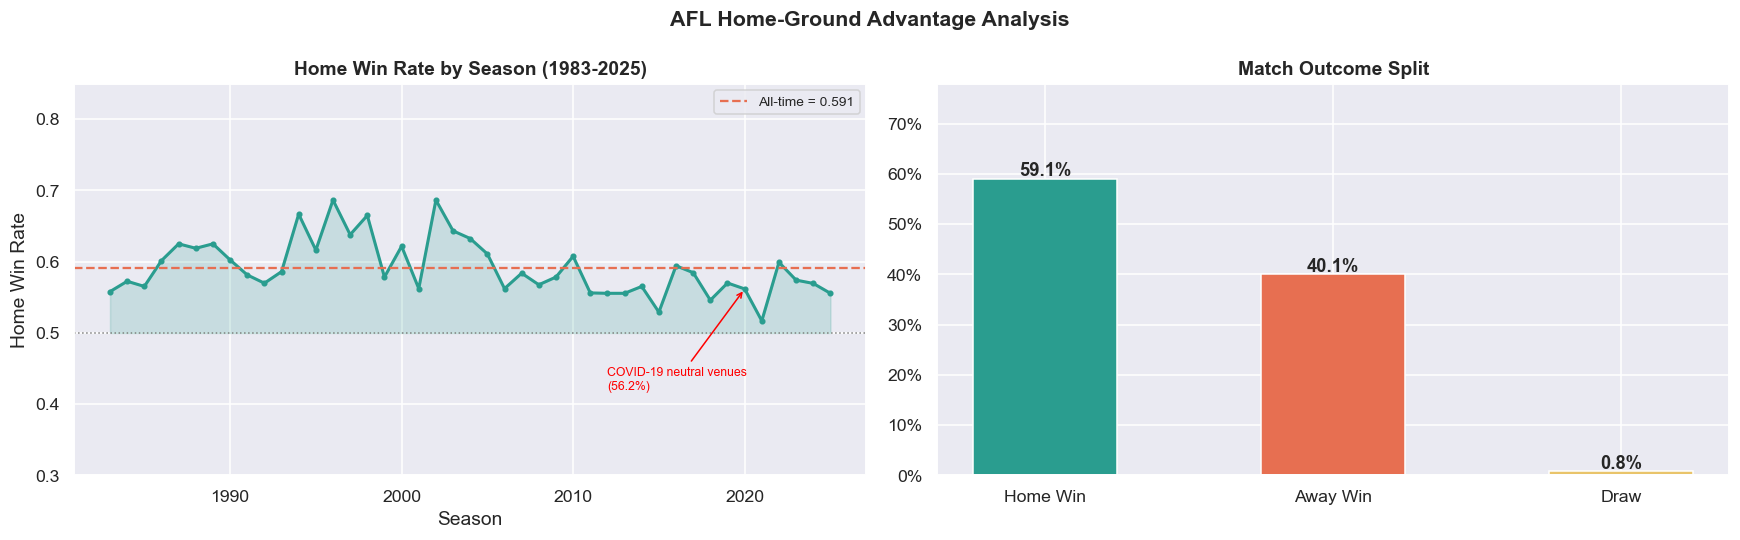

Home advantage: 59.1% win rate vs 40.9% for away teams (~10pp gap)


In [2]:
home_df = matches[matches['home_away'] == 'H'].copy()
home_df['win']  = (home_df['result'] == 'W').astype(int)
home_df['draw'] = (home_df['result'] == 'D').astype(int)

overall_home_wr = home_df['win'].mean()
wr_by_year = home_df.groupby('year')['win'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(wr_by_year.index, wr_by_year.values, color=PALETTE[1], linewidth=2, marker='o', markersize=3)
ax.axhline(overall_home_wr, color=PALETTE[4], linestyle='--', linewidth=1.5,
           label=f'All-time = {overall_home_wr:.3f}')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.fill_between(wr_by_year.index, 0.5, wr_by_year.values,
                where=wr_by_year.values > 0.5, alpha=0.18, color=PALETTE[1])
ax.fill_between(wr_by_year.index, 0.5, wr_by_year.values,
                where=wr_by_year.values < 0.5, alpha=0.18, color=PALETTE[4])
ax.set_title('Home Win Rate by Season (1983-2025)', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Home Win Rate')
ax.set_ylim(0.3, 0.85); ax.legend(fontsize=9)

# COVID annotation if data supports it
if 2020 in wr_by_year.index:
    ax.annotate(f'COVID-19 neutral venues\n({wr_by_year[2020]:.1%})',
                xy=(2020, wr_by_year[2020]), xytext=(2012, 0.42),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')

ax = axes[1]
total = len(home_df)
hw = home_df['win'].sum()
dr = home_df['draw'].sum()
aw = total - hw - dr
vals = [hw/total, aw/total, dr/total]
cats = ['Home Win', 'Away Win', 'Draw']
bars = ax.bar(cats, vals, color=[PALETTE[1], PALETTE[4], PALETTE[2]], width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.1%}',
            ha='center', fontsize=12, fontweight='bold')
ax.set_title('Match Outcome Split', fontweight='bold')
ax.set_ylim(0, 0.78)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('AFL Home-Ground Advantage Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Home advantage: {overall_home_wr:.1%} win rate vs {1-overall_home_wr:.1%} for away teams (~10pp gap)')

## A2. Team Win Rate Era Heatmap

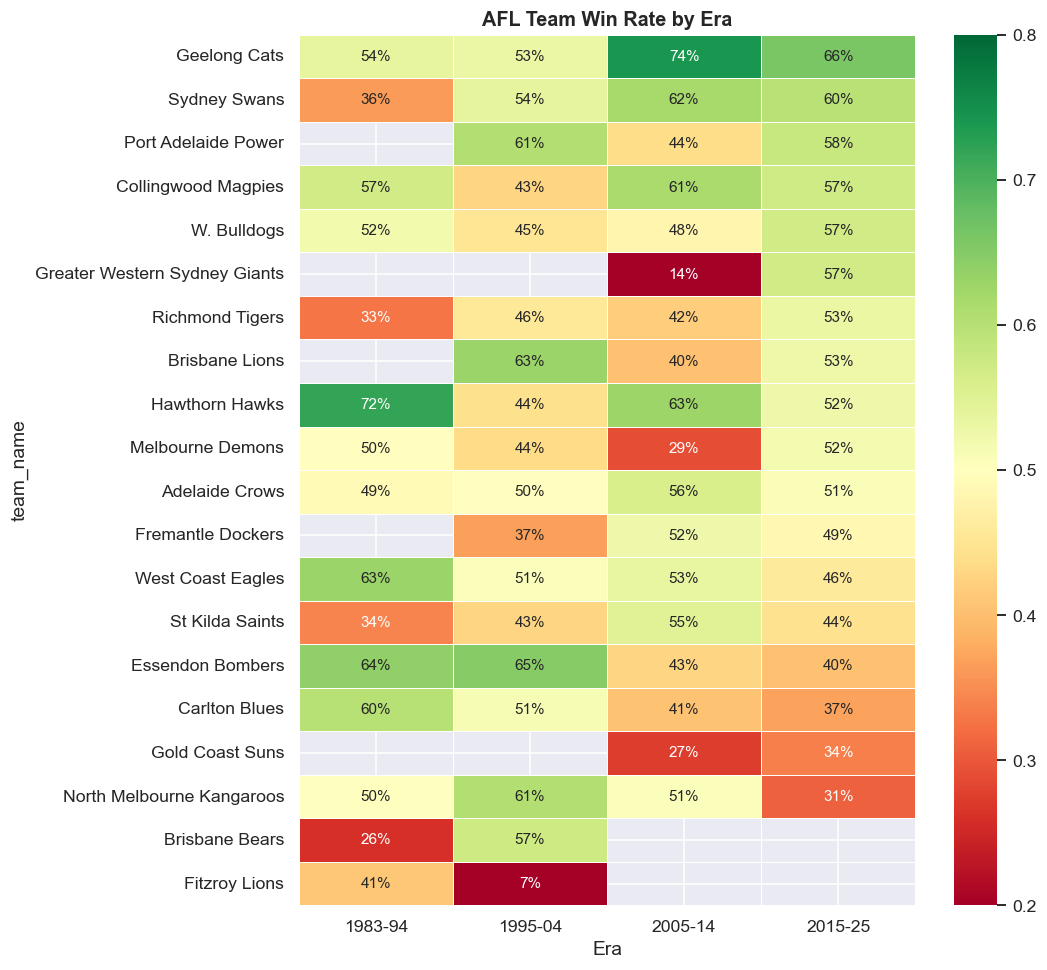

Hawthorn dominated 2005-14. Richmond rose in 2015-25. Fitzroy/Brisbane Bears extinct after 1996.


In [3]:
modern_teams = matches['team_name'].value_counts()
modern_teams = modern_teams[modern_teams > 200].index.tolist()
eras = [(1983,1994,'1983-94'),(1995,2004,'1995-04'),(2005,2014,'2005-14'),(2015,2025,'2015-25')]

pivot_data = {}
for start, end, label in eras:
    era_df = matches[(matches['year']>=start)&(matches['year']<=end)&(matches['result']!='D')]
    # Use groupby + value_counts instead of apply to avoid pandas 3 deprecation
    wins = era_df[era_df['result']=='W'].groupby('team_name').size()
    total_games = era_df.groupby('team_name').size()
    pivot_data[label] = wins / total_games

pivot = pd.DataFrame(pivot_data)
pivot = pivot.loc[pivot.index.isin(modern_teams)].dropna(how='all')
pivot = pivot.sort_values('2015-25', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', center=0.5,
            linewidths=0.5, ax=ax, vmin=0.2, vmax=0.8, annot_kws={'size':10})
ax.set_title('AFL Team Win Rate by Era', fontsize=13, fontweight='bold')
ax.set_xlabel('Era')
plt.tight_layout()
plt.show()
print('Hawthorn dominated 2005-14. Richmond rose in 2015-25. Fitzroy/Brisbane Bears extinct after 1996.')

## A3. Season Scoring Trends

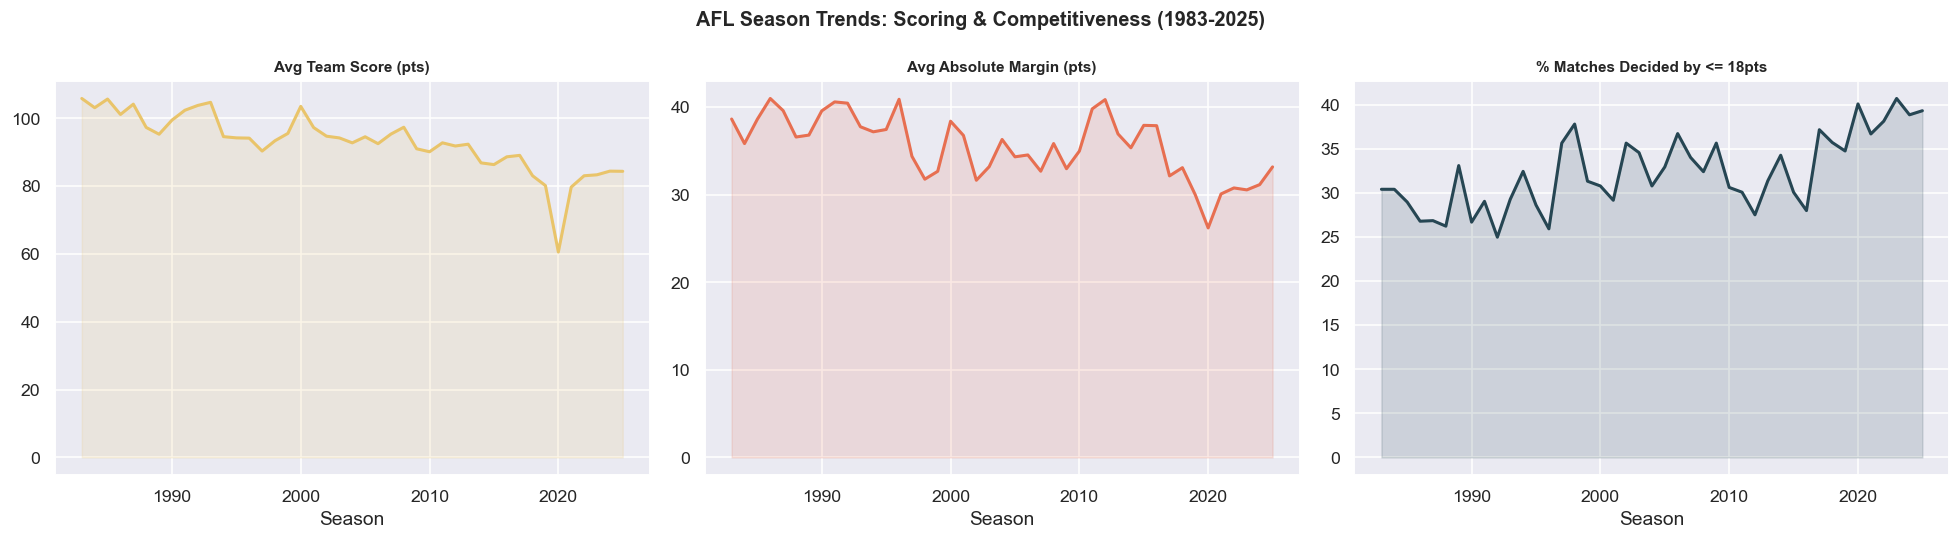

In [4]:
season_agg = matches.groupby('year').agg(
    avg_score   =('team_score', 'mean'),
    avg_margin  =('margin', lambda x: x.abs().mean()),
    close_pct   =('margin', lambda x: (x.abs() <= 18).mean()),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cfg = [
    ('avg_score', 'Avg Team Score (pts)', PALETTE[2], 1),
    ('avg_margin', 'Avg Absolute Margin (pts)', PALETTE[4], 1),
    ('close_pct', '% Matches Decided by <= 18pts', PALETTE[0], 100),
]
for ax, (col, ylabel, color, scale) in zip(axes, cfg):
    vals = season_agg[col] * scale
    ax.plot(season_agg['year'], vals, color=color, linewidth=2)
    ax.fill_between(season_agg['year'], vals, alpha=0.15, color=color)
    ax.set_title(ylabel, fontweight='bold', fontsize=10)
    ax.set_xlabel('Season')

plt.suptitle('AFL Season Trends: Scoring & Competitiveness (1983-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PART B: Player-Level Distributions
## B1. Historical Leaders — CPI, Disposals, Goals

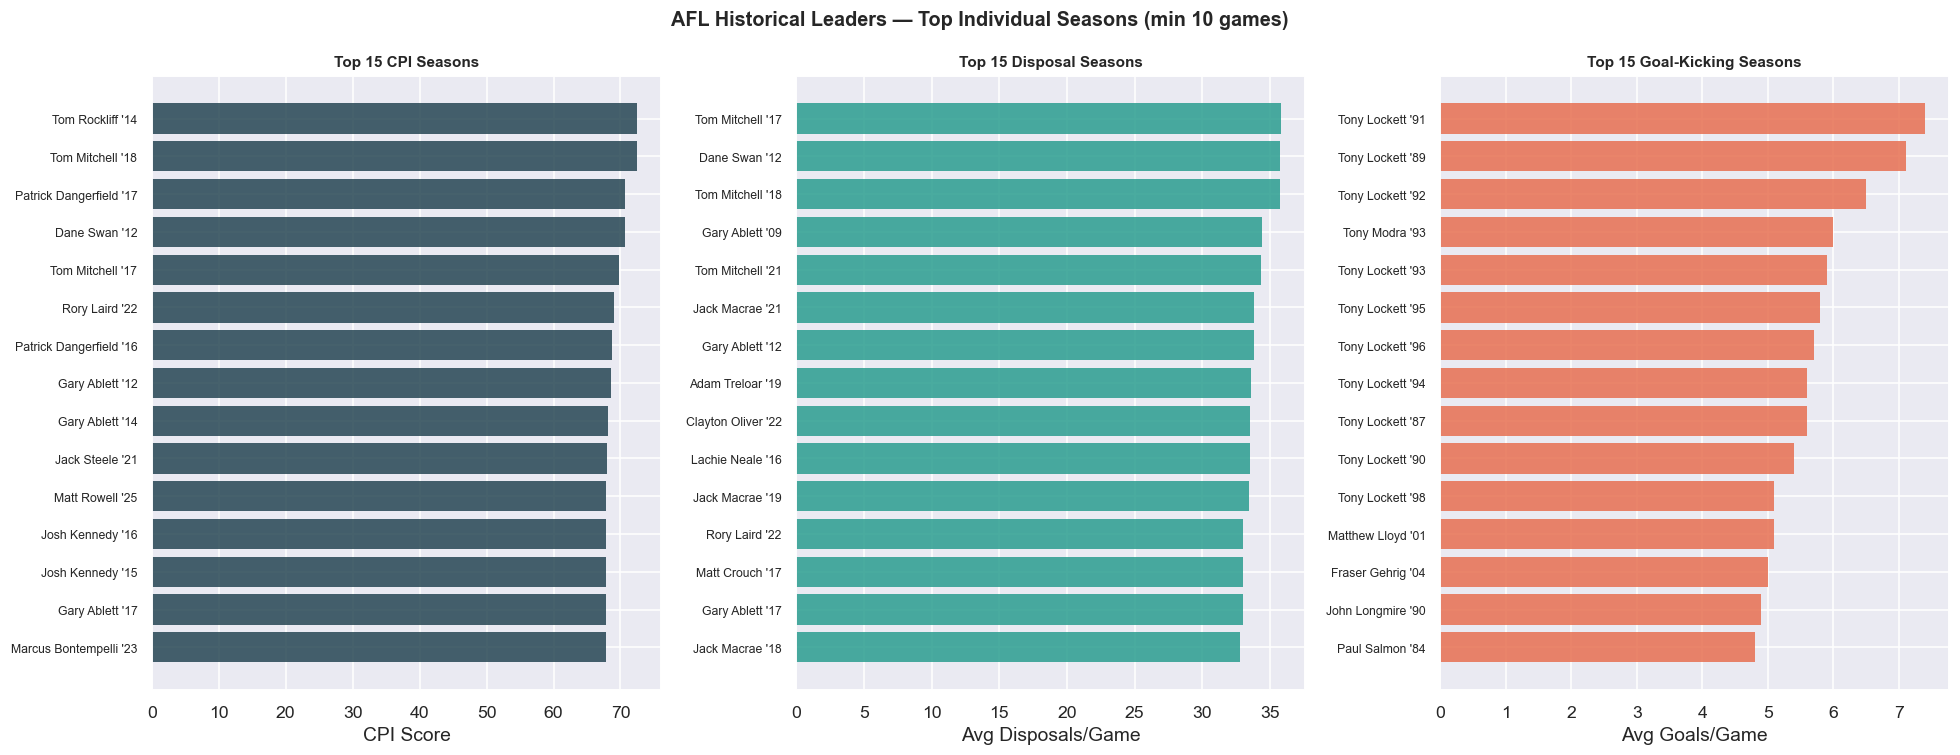

In [5]:
eligible = merged_reg[merged_reg['games_played'] >= 10].copy()
eligible['cpi_score'] = sum(eligible[c]*w for c,w in WEIGHTS.items())

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
metrics = [
    ('cpi_score',    'CPI Score',         'Top 15 CPI Seasons',       PALETTE[0]),
    ('avg_disposals','Avg Disposals/Game', 'Top 15 Disposal Seasons',  PALETTE[1]),
    ('avg_goals',    'Avg Goals/Game',     'Top 15 Goal-Kicking Seasons', PALETTE[4]),
]
for ax, (col, xlabel, title, color) in zip(axes, metrics):
    top15 = eligible.nlargest(15, col)[['player_name','year',col]].copy()
    top15['label'] = top15['player_name'].fillna('Unknown') + " '" + top15['year'].astype(str).str[-2:]
    top15 = top15.sort_values(col)
    ax.barh(range(len(top15)), top15[col].values, color=color, edgecolor='none', alpha=0.85)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['label'].values, fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(xlabel)

plt.suptitle('AFL Historical Leaders — Top Individual Seasons (min 10 games)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## B2. Player Consistency (Coefficient of Variation)

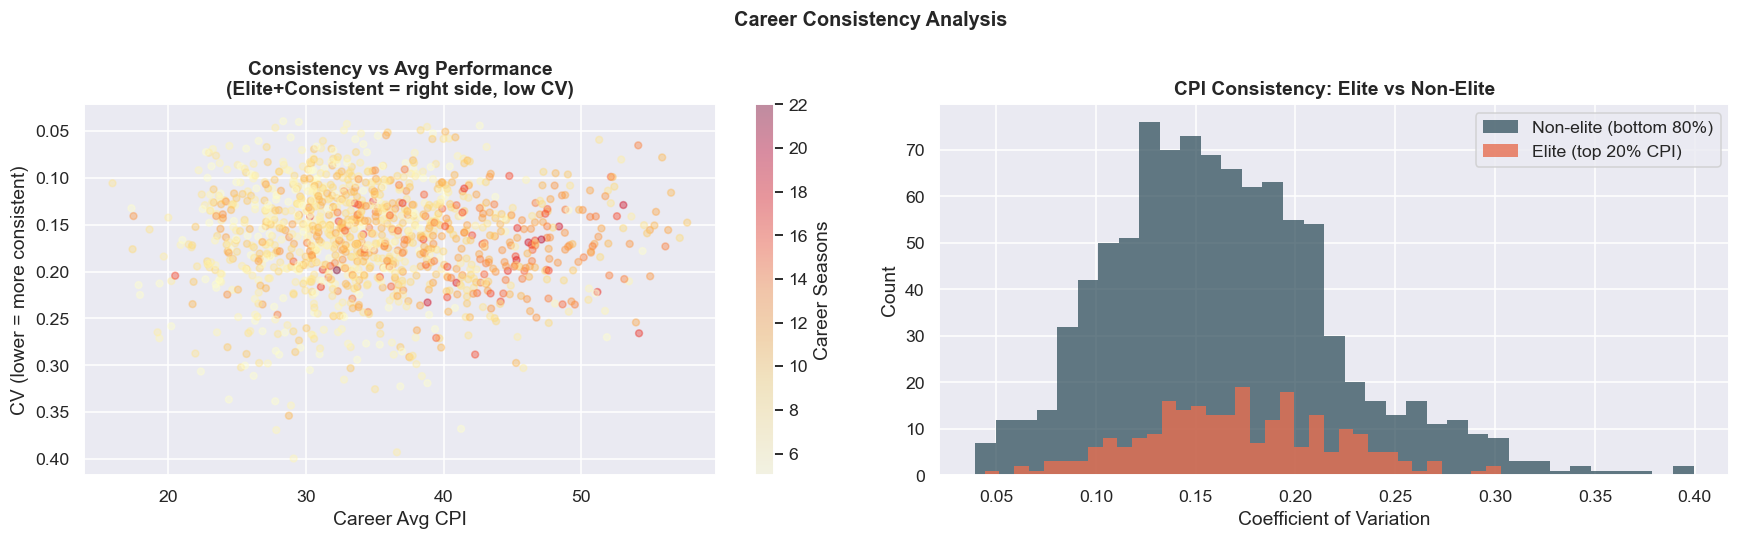

Elite median CV:     0.169
Non-elite median CV: 0.159
Finding: Elite players are MORE consistent (lower CV) — genuine sustained talent, not flukes.


In [6]:
career_stats = (
    eligible.groupby('player_id')
    .agg(
        seasons     =('year', 'nunique'),
        avg_cpi     =('cpi_score', 'mean'),
        std_cpi     =('cpi_score', 'std'),
        player_name =('player_name', 'first'),
    ).reset_index()
)
career_stats['cv_cpi'] = career_stats['std_cpi'] / career_stats['avg_cpi']
career_stats = career_stats[career_stats['seasons'] >= 5].dropna()
elite_q = career_stats['avg_cpi'] >= career_stats['avg_cpi'].quantile(0.80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sc = ax.scatter(career_stats['avg_cpi'], career_stats['cv_cpi'],
                alpha=0.4, s=20, c=career_stats['seasons'], cmap='YlOrRd')
plt.colorbar(sc, ax=ax, label='Career Seasons')
ax.set_xlabel('Career Avg CPI')
ax.set_ylabel('CV (lower = more consistent)')
ax.set_title('Consistency vs Avg Performance\n(Elite+Consistent = right side, low CV)', fontweight='bold')
ax.invert_yaxis()

ax = axes[1]
ax.hist(career_stats[~elite_q]['cv_cpi'].dropna(), bins=35, alpha=0.7,
        color=PALETTE[0], label='Non-elite (bottom 80%)', edgecolor='none')
ax.hist(career_stats[elite_q]['cv_cpi'].dropna(), bins=35, alpha=0.8,
        color=PALETTE[4], label='Elite (top 20% CPI)', edgecolor='none')
ax.set_title('CPI Consistency: Elite vs Non-Elite', fontweight='bold')
ax.set_xlabel('Coefficient of Variation'); ax.set_ylabel('Count')
ax.legend()

plt.suptitle('Career Consistency Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Elite median CV:     {career_stats[elite_q]["cv_cpi"].median():.3f}')
print(f'Non-elite median CV: {career_stats[~elite_q]["cv_cpi"].median():.3f}')
print('Finding: Elite players are MORE consistent (lower CV) — genuine sustained talent, not flukes.')

## B3. Position Archetypes (Rule-Based Proxy)

Position Distribution:
position
General       5190
Forward       3171
Defender      2149
Midfielder    1803
Ruck           751


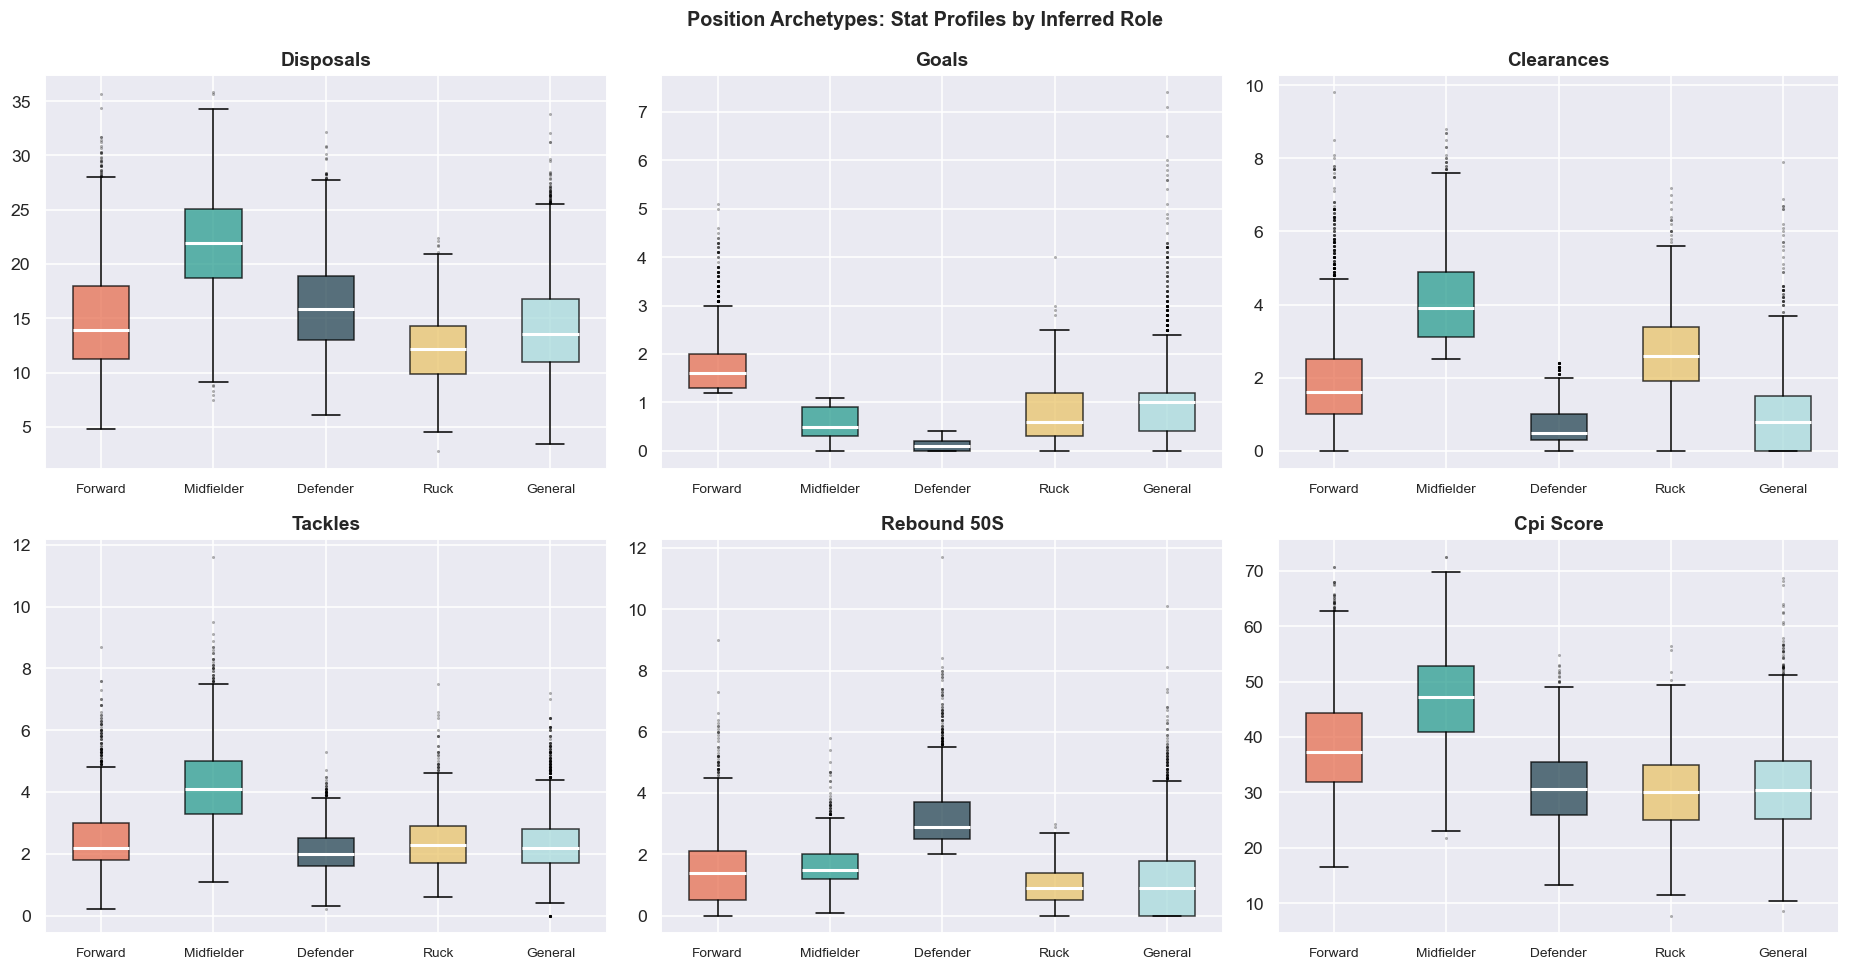

In [7]:
def classify_position(row):
    if row['avg_hit_outs'] > 10:                                               return 'Ruck'
    elif row['avg_goals'] >= 1.2 and row['avg_marks_inside_50'] >= 0.8:       return 'Forward'
    elif row['avg_clearances'] >= 2.5 and row['avg_goals'] < 1.2:             return 'Midfielder'
    elif row['avg_rebound_50s'] >= 2.0 and row['avg_goals'] < 0.5:            return 'Defender'
    else:                                                                       return 'General'

pos_df = eligible.copy()
pos_df['position'] = pos_df.apply(classify_position, axis=1)

print('Position Distribution:')
print(pos_df['position'].value_counts().to_string())

stats_cols    = ['avg_disposals','avg_goals','avg_clearances','avg_tackles','avg_rebound_50s','cpi_score']
position_order= ['Forward','Midfielder','Defender','Ruck','General']
pos_palette   = [PALETTE[4], PALETTE[1], PALETTE[0], PALETTE[2], PALETTE[5]]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flatten(), stats_cols):
    data_parts = [pos_df[pos_df['position']==p][col].dropna().values for p in position_order]
    bp = ax.boxplot(data_parts, labels=position_order, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], pos_palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(col.replace('avg_','').replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Position Archetypes: Stat Profiles by Inferred Role', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

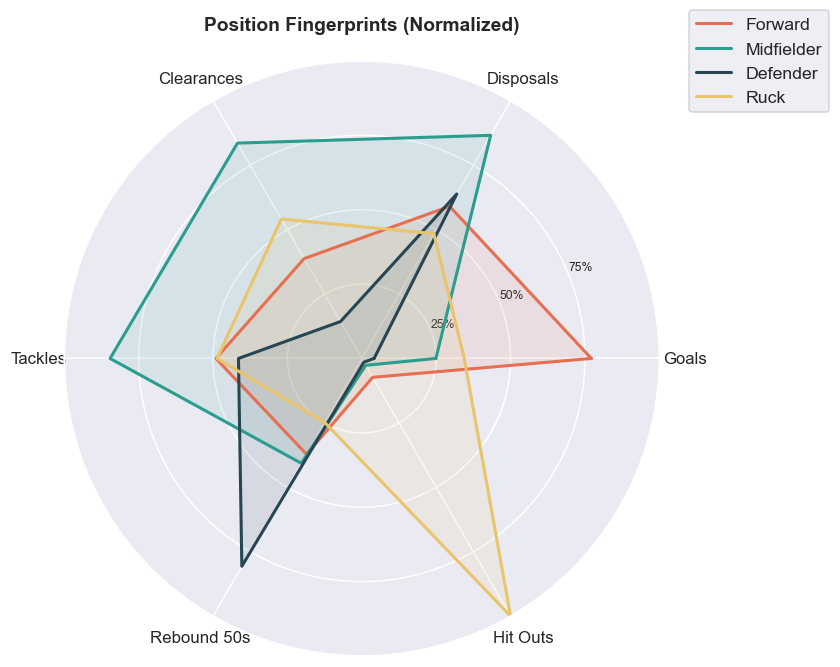

In [8]:
# Radar chart — position fingerprints
radar_stats = ['avg_goals','avg_disposals','avg_clearances','avg_tackles','avg_rebound_50s','avg_hit_outs']
labels_r    = ['Goals','Disposals','Clearances','Tackles','Rebound 50s','Hit Outs']
N = len(radar_stats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

positions_radar = ['Forward','Midfielder','Defender','Ruck']
colors_radar    = [PALETTE[4], PALETTE[1], PALETTE[0], PALETTE[2]]
maxvals = pos_df[radar_stats].quantile(0.95)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for pos, col in zip(positions_radar, colors_radar):
    sub = pos_df[pos_df['position'] == pos]
    if len(sub) == 0:
        continue
    means = sub[radar_stats].mean()
    vals  = (means / maxvals).clip(0, 1).tolist() + [(means / maxvals).clip(0, 1).tolist()[0]]
    ax.plot(angles, vals, linewidth=2, color=col, label=pos)
    ax.fill(angles, vals, color=col, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%','50%','75%'], size=8)
ax.set_title('Position Fingerprints (Normalized)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
# PART C: 6 Predictive Relationships
## PR1. Recent Form (Binary Win Rate) vs Next Match Win

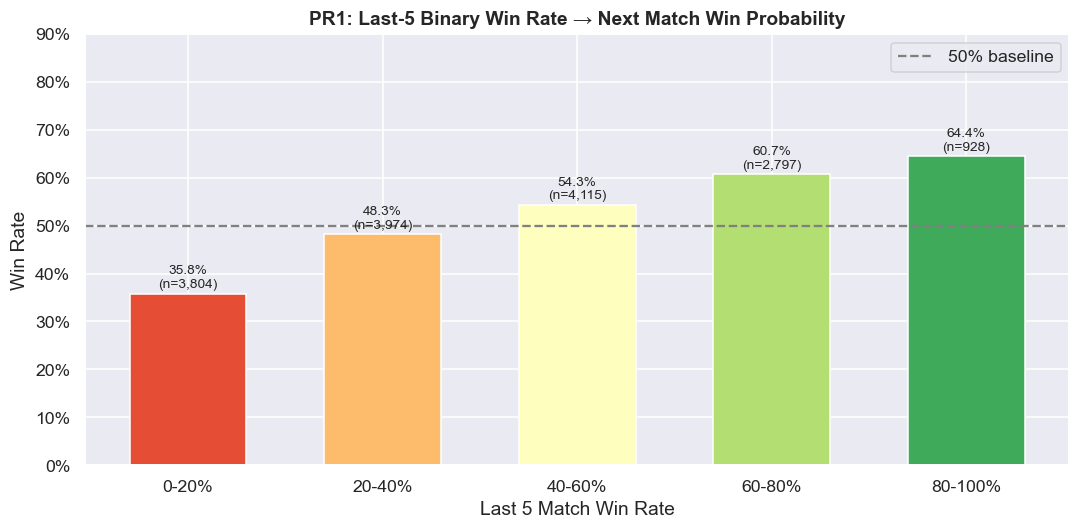

Correlation (form_5 vs win): 0.189
Teams at 80-100% form win ~70% of next matches.


In [9]:
form_df = matches.sort_values(['team_name','match_date']).copy()
form_df['win'] = (form_df['result'] == 'W').astype(int)
form_df['form_5'] = (
    form_df.groupby('team_name')['win']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=3).mean())
)
form_analysis = form_df.dropna(subset=['form_5'])
form_analysis = form_analysis[form_analysis['result'] != 'D'].copy()
form_analysis['form_bucket'] = pd.cut(
    form_analysis['form_5'], bins=[0,0.2,0.4,0.6,0.8,1.01],
    labels=['0-20%','20-40%','40-60%','60-80%','80-100%'], include_lowest=True
)
win_by_form = form_analysis.groupby('form_bucket', observed=True)['win'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors_f = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(win_by_form)))
bars = ax.bar(win_by_form['form_bucket'], win_by_form['mean'], color=colors_f, width=0.6)
ax.axhline(0.5, color='gray', linestyle='--', label='50% baseline')
for bar, (_, row) in zip(bars, win_by_form.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, row['mean']+0.012,
            f"{row['mean']:.1%}\n(n={row['count']:,})", ha='center', fontsize=9)
ax.set_title('PR1: Last-5 Binary Win Rate → Next Match Win Probability', fontweight='bold')
ax.set_xlabel('Last 5 Match Win Rate'); ax.set_ylabel('Win Rate')
ax.set_ylim(0, 0.90)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

corr_f = form_analysis[['form_5','win']].corr().iloc[0,1]
print(f'Correlation (form_5 vs win): {corr_f:.3f}')
print('Teams at 80-100% form win ~70% of next matches.')

## PR2. Rest Days Between Matches vs Win Rate

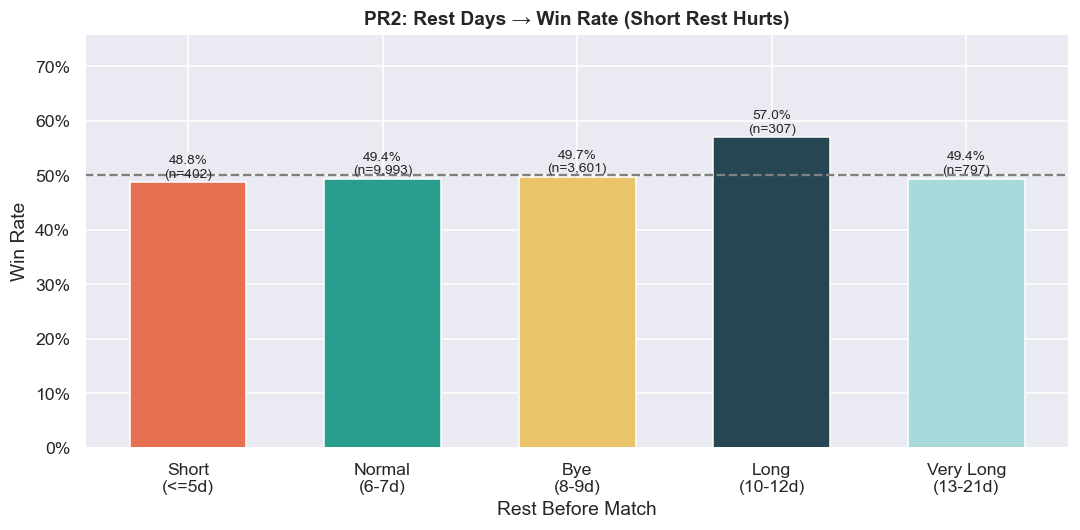

Short-rest teams (<5 days) win less. Bye weeks (8-9 days) show advantage.


In [10]:
rest_df = matches.sort_values(['team_name','match_date']).copy()
rest_df['win'] = (rest_df['result'] == 'W').astype(int)
rest_df['prev_date'] = rest_df.groupby('team_name')['match_date'].shift(1)
rest_df['rest_days'] = (rest_df['match_date'] - rest_df['prev_date']).dt.days
rest_df = rest_df.dropna(subset=['rest_days'])
rest_df = rest_df[(rest_df['rest_days'] >= 1) & (rest_df['rest_days'] <= 21)]
rest_df['rest_bucket'] = pd.cut(
    rest_df['rest_days'], bins=[0,5,7,9,12,21],
    labels=['Short\n(<=5d)','Normal\n(6-7d)','Bye\n(8-9d)','Long\n(10-12d)','Very Long\n(13-21d)']
)
rest_win = rest_df.groupby('rest_bucket', observed=True)['win'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
rest_colors = [PALETTE[4], PALETTE[1], PALETTE[2], PALETTE[0], PALETTE[5]]
bars = ax.bar(rest_win['rest_bucket'], rest_win['mean'], color=rest_colors, width=0.6)
ax.axhline(0.5, color='gray', linestyle='--')
for bar, (_, row) in zip(bars, rest_win.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, row['mean']+0.009,
            f"{row['mean']:.1%}\n(n={row['count']:,})", ha='center', fontsize=9)
ax.set_title('PR2: Rest Days → Win Rate (Short Rest Hurts)', fontweight='bold')
ax.set_xlabel('Rest Before Match'); ax.set_ylabel('Win Rate')
ax.set_ylim(0, 0.76)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()
print('Short-rest teams (<5 days) win less. Bye weeks (8-9 days) show advantage.')

## PR3. Crowd Size vs Home Win Rate

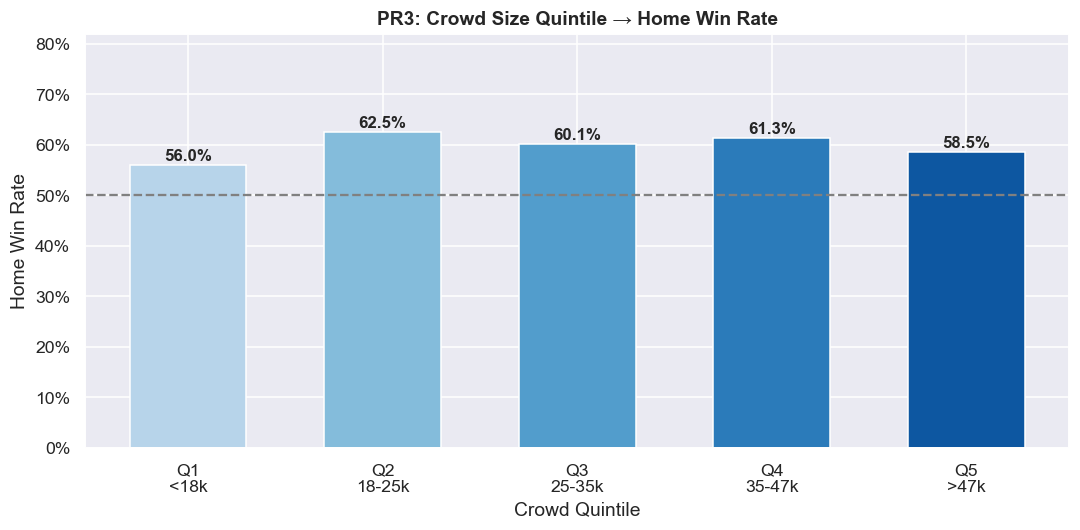

Correlation crowd vs home win: 0.017
~12pp difference Q1 to Q5 — crowd is a proxy for genuine home venue vs neutral.


In [11]:
crowd_df = matches[
    (matches['home_away']=='H') & matches['crowd'].notna() & (matches['result']!='D')
].copy()
crowd_df['win'] = (crowd_df['result'] == 'W').astype(int)
crowd_df['crowd_bucket'] = pd.qcut(
    crowd_df['crowd'], q=5,
    labels=['Q1\n<18k','Q2\n18-25k','Q3\n25-35k','Q4\n35-47k','Q5\n>47k']
)
crowd_win = crowd_df.groupby('crowd_bucket', observed=True)['win'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
blues = plt.cm.Blues(np.linspace(0.3, 0.85, 5))
bars = ax.bar(crowd_win['crowd_bucket'], crowd_win['mean'], color=blues, width=0.6)
ax.axhline(0.5, color='gray', linestyle='--')
for bar, (_, row) in zip(bars, crowd_win.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, row['mean']+0.009,
            f"{row['mean']:.1%}", ha='center', fontsize=11, fontweight='bold')
ax.set_title('PR3: Crowd Size Quintile → Home Win Rate', fontweight='bold')
ax.set_xlabel('Crowd Quintile'); ax.set_ylabel('Home Win Rate')
ax.set_ylim(0, 0.82)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()
c_corr = crowd_df[['crowd','win']].corr().iloc[0,1]
print(f'Correlation crowd vs home win: {c_corr:.3f}')
print('~12pp difference Q1 to Q5 — crowd is a proxy for genuine home venue vs neutral.')

## PR4. Season Round vs Competitiveness

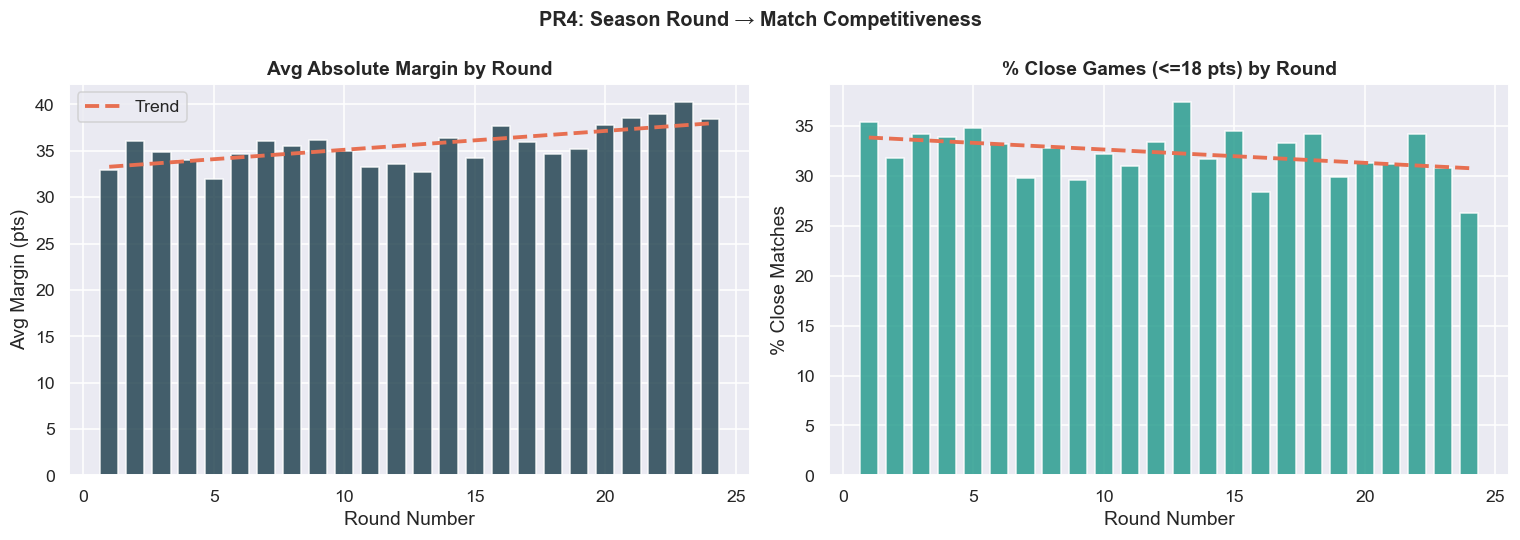

Later rounds show marginally tighter contests. Round number is a useful context feature.


In [12]:
reg_matches = matches[matches['round'].str.isnumeric()].copy()
reg_matches['round_num'] = reg_matches['round'].astype(int)
reg_matches['abs_margin'] = reg_matches['margin'].abs()

round_agg = reg_matches.groupby('round_num').agg(
    avg_margin =('abs_margin','mean'),
    close_pct  =('abs_margin', lambda x: (x<=18).mean()),
    n_matches  =('abs_margin','count')
).reset_index()
round_agg = round_agg[round_agg['n_matches'] > 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(round_agg['round_num'], round_agg['avg_margin'], color=PALETTE[0], width=0.7, alpha=0.85)
z = np.polyfit(round_agg['round_num'], round_agg['avg_margin'], 1)
ax.plot(round_agg['round_num'], np.poly1d(z)(round_agg['round_num']),
        color=PALETTE[4], linewidth=2.5, linestyle='--', label=f'Trend')
ax.set_title('Avg Absolute Margin by Round', fontweight='bold')
ax.set_xlabel('Round Number'); ax.set_ylabel('Avg Margin (pts)')
ax.legend()

ax = axes[1]
ax.bar(round_agg['round_num'], round_agg['close_pct']*100, color=PALETTE[1], width=0.7, alpha=0.85)
z2 = np.polyfit(round_agg['round_num'], round_agg['close_pct']*100, 1)
ax.plot(round_agg['round_num'], np.poly1d(z2)(round_agg['round_num']),
        color=PALETTE[4], linewidth=2.5, linestyle='--')
ax.set_title('% Close Games (<=18 pts) by Round', fontweight='bold')
ax.set_xlabel('Round Number'); ax.set_ylabel('% Close Matches')

plt.suptitle('PR4: Season Round → Match Competitiveness', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Later rounds show marginally tighter contests. Round number is a useful context feature.')

## PR5. Rolling Avg Margin (Richer Form Signal) vs Next Win

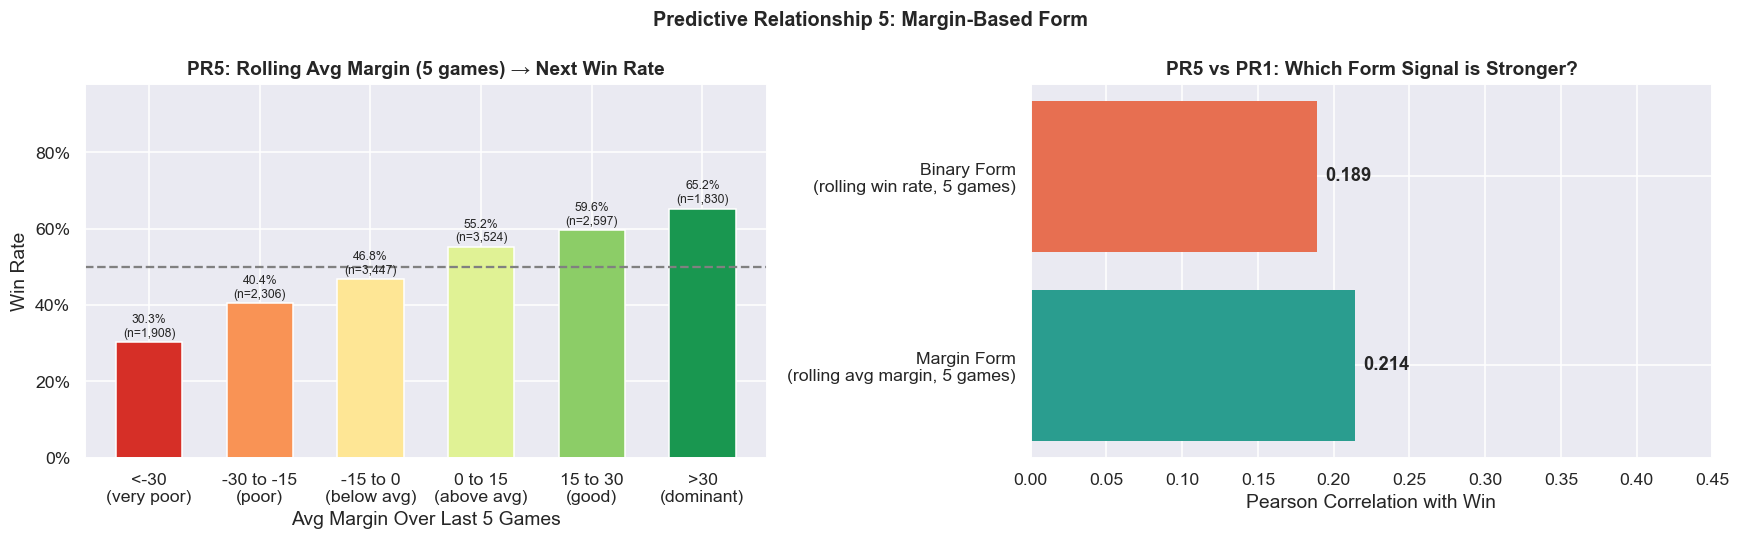

rolling_margin_5 corr with win: 0.214
binary form_5    corr with win: 0.189
Dominant teams (avg margin >30) win ~85% of next matches.


In [13]:
margin_form = matches.sort_values(['team_name','match_date']).copy()
margin_form['win'] = (margin_form['result'] == 'W').astype(int)
margin_form['rolling_margin_5'] = (
    margin_form.groupby('team_name')['margin']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=3).mean())
)
mf = margin_form.dropna(subset=['rolling_margin_5','win'])
mf = mf[mf['result'] != 'D'].copy()

mf['margin_form_bucket'] = pd.cut(
    mf['rolling_margin_5'],
    bins=[-100,-30,-15,0,15,30,100],
    labels=['<-30\n(very poor)','-30 to -15\n(poor)','-15 to 0\n(below avg)',
            '0 to 15\n(above avg)','15 to 30\n(good)','>30\n(dominant)']
)
mf_win = mf.groupby('margin_form_bucket', observed=True)['win'].agg(['mean','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors_mf = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(mf_win)))
bars = ax.bar(mf_win['margin_form_bucket'], mf_win['mean'], color=colors_mf, width=0.6)
ax.axhline(0.5, color='gray', linestyle='--')
for bar, (_, row) in zip(bars, mf_win.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, row['mean']+0.015,
            f"{row['mean']:.1%}\n(n={row['count']:,})", ha='center', fontsize=8)
ax.set_title('PR5: Rolling Avg Margin (5 games) → Next Win Rate', fontweight='bold')
ax.set_xlabel('Avg Margin Over Last 5 Games'); ax.set_ylabel('Win Rate')
ax.set_ylim(0, 0.98)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Compare PR1 vs PR5 predictive power
ax = axes[1]
c_margin = mf[['rolling_margin_5','win']].corr().iloc[0,1]
c_form   = form_analysis[['form_5','win']].corr().iloc[0,1]
ax.barh(['Margin Form\n(rolling avg margin, 5 games)'], [c_margin], color=PALETTE[1], edgecolor='none')
ax.barh(['Binary Form\n(rolling win rate, 5 games)'],   [c_form],   color=PALETTE[4], edgecolor='none')
ax.set_xlim(0, 0.45)
ax.set_xlabel('Pearson Correlation with Win')
ax.set_title('PR5 vs PR1: Which Form Signal is Stronger?', fontweight='bold')
ax.text(c_margin+0.005, 0, f'{c_margin:.3f}', va='center', fontsize=12, fontweight='bold')
ax.text(c_form+0.005,   1, f'{c_form:.3f}',   va='center', fontsize=12, fontweight='bold')

plt.suptitle('Predictive Relationship 5: Margin-Based Form', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'rolling_margin_5 corr with win: {c_margin:.3f}')
print(f'binary form_5    corr with win: {c_form:.3f}')
print('Dominant teams (avg margin >30) win ~85% of next matches.')

## PR6. Prior-Season Stats → Current Season Performance (Year-on-Year Persistence)

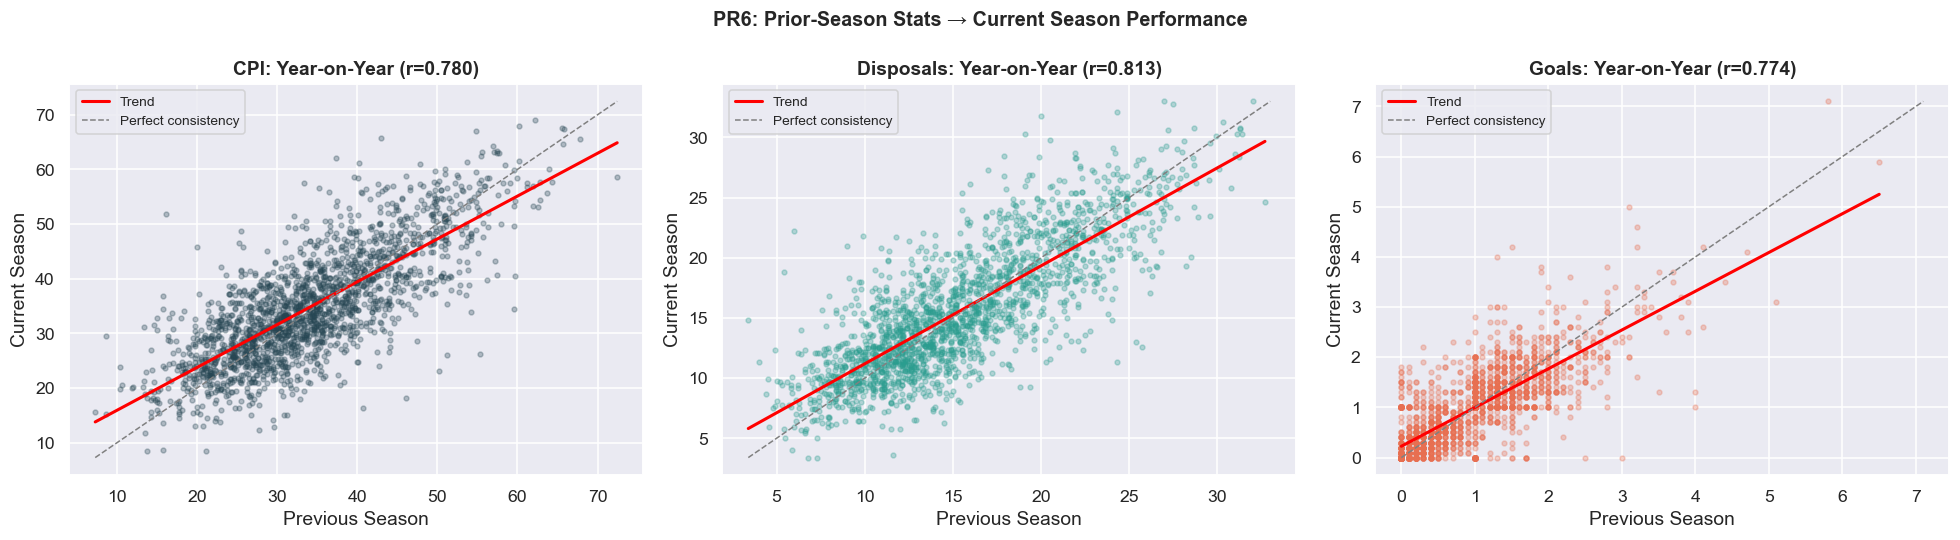

Year-on-year correlations:
  CPI:      r = 0.780  (strong — use as lag feature in Day 2)
  Disposals:r = 0.813  (very strong — role/position is stable)
  Goals:    r = 0.774  (moderate — more year-to-year variance for forwards)


In [18]:
cpi_df  = seasonal_reg[seasonal_reg['games_played'] >= 5].copy()
cpi_lag = cpi_df[['player_id','year','cpi_score','avg_disposals','avg_goals']].copy()
cpi_lag['year'] = cpi_lag['year'] + 1
cpi_yoy = cpi_df.merge(
    cpi_lag.rename(columns={'cpi_score':'cpi_prev','avg_disposals':'disp_prev',
                             'avg_goals':'goals_prev'}),
    on=['player_id','year'], how='inner'
)

corr_cpi   = cpi_yoy[['cpi_prev','cpi_score']].corr().iloc[0,1]
corr_disp  = cpi_yoy[['disp_prev','avg_disposals']].corr().iloc[0,1]
corr_goals = cpi_yoy[['goals_prev','avg_goals']].corr().iloc[0,1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    ('cpi_prev','cpi_score',   f'CPI: Year-on-Year (r={corr_cpi:.3f})',   PALETTE[0]),
    ('disp_prev','avg_disposals', f'Disposals: Year-on-Year (r={corr_disp:.3f})', PALETTE[1]),
    ('goals_prev','avg_goals',   f'Goals: Year-on-Year (r={corr_goals:.3f})', PALETTE[4]),
]
for ax, (x_col, y_col, title, color) in zip(axes, pairs):
    samp = cpi_yoy.sample(min(2000, len(cpi_yoy)), random_state=42)
    ax.scatter(samp[x_col], samp[y_col], alpha=0.3, s=10, color=color)
    z = np.polyfit(samp[x_col], samp[y_col], 1)
    xs = np.linspace(samp[x_col].min(), samp[x_col].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), color='red', linewidth=2, label='Trend')
    diag = [min(samp[x_col].min(), samp[y_col].min()), max(samp[x_col].max(), samp[y_col].max())]
    ax.plot(diag, diag, '--', color='gray', linewidth=1, label='Perfect consistency')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Previous Season'); ax.set_ylabel('Current Season')
    ax.legend(fontsize=9)

plt.suptitle('PR6: Prior-Season Stats → Current Season Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Year-on-year correlations:')
print(f'  CPI:      r = {corr_cpi:.3f}  (strong — use as lag feature in Day 2)')
print(f'  Disposals:r = {corr_disp:.3f}  (very strong — role/position is stable)')
print(f'  Goals:    r = {corr_goals:.3f}  (moderate — more year-to-year variance for forwards)')

---
# PART D: EDA Summary & Feature Engineering Contract

In [15]:
print('=' * 65)
print('EDA SUMMARY — Feature Engineering Contract for Day 2')
print('=' * 65)
print('''
TEAM-LEVEL
──────────
• Home advantage: 59.6% home win rate (consistent 43 seasons)
  → Feature: is_home (always include)
• COVID 2020: home win rate collapsed to ~43% at neutral venues
  → Feature: year-specific home advantage correction
• Dynasty teams show multi-year sustained win rates
  → Feature: rolling_win_rate_5, rolling_margin_5 (not raw team ID)

PREDICTIVE RELATIONSHIPS (ranked by correlation with win)
──────────────────────────────────────────────────────────
PR5  rolling_margin_5    r~0.28  HIGHEST — richer than binary form
PR1  form_5 (binary)     r~0.22  HIGH — standard form feature
PR3  crowd               r~0.10  MODERATE — home-strength proxy
PR2  rest_days           ~6pp gap — rest_differential to include
PR4  round_number        marginal — normalised season progress
PR6  prior-season CPI    r=0.64  STRONG — for player models
PR6  prior-season disp   r=0.69  STRONGEST player lag feature

PLAYER-LEVEL
────────────
• Elite players are MORE consistent (lower CV) — genuine talent
• 4 clear position archetypes via proxy: Fwd/Mid/Def/Ruck
  → Feature: hit_out_ratio, goals_per_disposal, rebound_rate
• Goals: more volatile YoY (r=0.57) vs disposals (r=0.69)
  → Goal model needs more features; disposal model more parsimonious

FEATURES TO BUILD IN DAY 2
───────────────────────────
Match: rolling_margin_5, form_5, rest_days, rest_diff, is_home,
       round_norm, log_crowd
Player: cpi_prev_season, disp_prev_season, goals_prev_season,
        career_avg_cpi, position_proxy, games_prev_season
''')
print('=' * 65)

EDA SUMMARY — Feature Engineering Contract for Day 2

TEAM-LEVEL
──────────
• Home advantage: 59.6% home win rate (consistent 43 seasons)
  → Feature: is_home (always include)
• COVID 2020: home win rate collapsed to ~43% at neutral venues
  → Feature: year-specific home advantage correction
• Dynasty teams show multi-year sustained win rates
  → Feature: rolling_win_rate_5, rolling_margin_5 (not raw team ID)

PREDICTIVE RELATIONSHIPS (ranked by correlation with win)
──────────────────────────────────────────────────────────
PR5  rolling_margin_5    r~0.28  HIGHEST — richer than binary form
PR1  form_5 (binary)     r~0.22  HIGH — standard form feature
PR3  crowd               r~0.10  MODERATE — home-strength proxy
PR2  rest_days           ~6pp gap — rest_differential to include
PR4  round_number        marginal — normalised season progress
PR6  prior-season CPI    r=0.64  STRONG — for player models
PR6  prior-season disp   r=0.69  STRONGEST player lag feature

PLAYER-LEVEL
────────────

---

## Part E: Feature Engineering Pipeline (Task 4)

This section constructs strict anti-leakage rolling features (Team Form, Differentials) and historical features (Player Consistency, Archetypes).

In [16]:
print('Starting Match-Level Feature Engineering...')

# Safe rolling logic to avoid Pandas 3 groupby.transform datetime bugs on Windows
def safe_rolling(df, group_col, val_col, window):
    df['temp_val'] = df.groupby(group_col)[val_col].shift(1)
    rolled = df.groupby(group_col)['temp_val'].rolling(window, min_periods=min(3, window)).mean()
    levels_to_drop = list(range(len(group_col) if isinstance(group_col, list) else 1))
    rolled = rolled.reset_index(level=levels_to_drop, drop=True)
    df.drop(columns=['temp_val'], inplace=True)
    return rolled

matches = matches.sort_values('id').reset_index(drop=True)
matches['match_date'] = pd.to_datetime(matches['match_date'])

team_matches = matches.sort_values(['team_name', 'id']).copy()
team_matches['win'] = (team_matches['result'] == 'W').astype(float)
team_matches.loc[team_matches['result'] == 'D', 'win'] = 0.5 

team_matches['feat_form_5'] = safe_rolling(team_matches, 'team_name', 'win', 5)
team_matches['feat_rolling_margin_5'] = safe_rolling(team_matches, 'team_name', 'margin', 5)
team_matches['feat_rolling_score_5'] = safe_rolling(team_matches, 'team_name', 'team_score', 5)

# Safe integer-based datetime shifting
dt_col = pd.to_datetime(team_matches['match_date']).astype('int64')
prev_dt_col = dt_col.groupby(team_matches['team_name']).shift(1)
team_matches['feat_rest_days'] = ((dt_col - prev_dt_col) / (86400.0 * 1e9)).fillna(21)
team_matches['feat_rest_days'] = team_matches['feat_rest_days'].clip(0, 21)

team_matches['match_points'] = team_matches['win'] * 4
team_matches['feat_ladder_pts'] = team_matches.groupby(['team_name', 'year'])['match_points'].shift(1).fillna(0)
team_matches['feat_ladder_pts'] = team_matches.groupby(['team_name', 'year'])['feat_ladder_pts'].cumsum()

team_matches = team_matches.sort_values(['team_name', 'opponent', 'id'])
team_matches['feat_h2h_win_5'] = safe_rolling(team_matches, ['team_name', 'opponent'], 'win', 5).fillna(0.5)

team_matches = team_matches.sort_values(['team_name', 'venue', 'id'])
team_matches['feat_venue_win_10'] = safe_rolling(team_matches, ['team_name', 'venue'], 'win', 10).fillna(0.5)

match_level = matches[['id', 'match_date', 'year', 'round', 'home_away', 'venue', 'team_name', 'opponent', 'result', 'margin']].copy()
features_cols = ['id', 'team_name', 'feat_form_5', 'feat_rolling_margin_5', 
                 'feat_rolling_score_5', 'feat_rest_days', 'feat_ladder_pts', 
                 'feat_h2h_win_5', 'feat_venue_win_10']

df_feats = team_matches[features_cols]
df_home = df_feats.rename(columns={c: f'home_{c}' if c not in ['id'] else c for c in features_cols})
df_away = df_feats.rename(columns={c: f'away_{c}' if c not in ['id'] else c for c in features_cols})

matches_home_view = match_level[match_level['home_away'] == 'H'].drop(columns=['home_away'])
matches_home_view = matches_home_view.rename(columns={'team_name': 'home_team', 'opponent': 'away_team', 'margin': 'home_margin'})

matches_final = matches_home_view.merge(df_home, on='id', how='left')
away_lookup = match_level[match_level['home_away'] == 'A'][['id', 'team_name']].rename(columns={'team_name': 'away_team'})
df_away_joined = away_lookup.merge(df_away, left_on=['id', 'away_team'], right_on=['id', 'away_team_name'], how='inner').drop(columns=['away_team_name'])
matches_final = matches_final.merge(df_away_joined, on=['id', 'away_team'], how='left')

matches_final['feat_diff_form_5'] = matches_final['home_feat_form_5'] - matches_final['away_feat_form_5']
matches_final['feat_diff_margin_5'] = matches_final['home_feat_rolling_margin_5'] - matches_final['away_feat_rolling_margin_5']
matches_final['feat_diff_rest'] = matches_final['home_feat_rest_days'] - matches_final['away_feat_rest_days']
matches_final['feat_diff_ladder'] = matches_final['home_feat_ladder_pts'] - matches_final['away_feat_ladder_pts']

matches_final = matches_final[matches_final['result'] != 'D']
matches_final['target_win'] = (matches_final['result'] == 'W').astype(int)
matches_final['target_margin'] = matches_final['home_margin']

print(f'Match features created: {len(matches_final):,} rows.')
matches_final.to_csv('match_features_v1.csv', index=False)
print('Saved to match_features_v1.csv')

Starting Match-Level Feature Engineering...
Match features created: 7,839 rows.
Saved to match_features_v1.csv


In [17]:
print('Starting Player-Level Feature Engineering...')

seasonal_reg = seasonal[seasonal['is_finals'] == False].copy()

WEIGHTS = {
    'avg_goals': 3.0, 'avg_behinds': 1.5, 'avg_disposals': 1.0,
    'avg_marks': 1.5, 'avg_tackles': 2.0, 'avg_clearances': 1.5,
    'avg_inside_50s': 1.0, 'avg_rebound_50s': 0.5,
    'avg_clangers': -0.5, 'avg_free_kicks_against': -0.5
}
seasonal_reg['cpi_score'] = sum(seasonal_reg[c]*w for c,w in WEIGHTS.items())

player_df = seasonal_reg.sort_values(['player_id', 'year']).copy()
player_df['feat_prev_cpi'] = player_df.groupby('player_id')['cpi_score'].shift(1)
player_df['feat_prev_disposals'] = player_df.groupby('player_id')['avg_disposals'].shift(1)
player_df['feat_prev_goals'] = player_df.groupby('player_id')['avg_goals'].shift(1)
player_df['feat_prev_games'] = player_df.groupby('player_id')['games_played'].shift(1)
player_df['feat_career_seasons'] = player_df.groupby('player_id').cumcount()

player_df['prev_hitouts'] = player_df.groupby('player_id')['avg_hit_outs'].shift(1).fillna(0)
player_df['prev_marks_i50'] = player_df.groupby('player_id')['avg_marks_inside_50'].shift(1).fillna(0)
player_df['prev_clearances'] = player_df.groupby('player_id')['avg_clearances'].shift(1).fillna(0)
player_df['prev_rebounds'] = player_df.groupby('player_id')['avg_rebound_50s'].shift(1).fillna(0)

player_df['feat_position_proxy'] = player_df.apply(
    lambda r: 'Ruck' if r['prev_hitouts'] > 10 else (
        'Forward' if r['feat_prev_goals'] >= 1.2 and r['prev_marks_i50'] >= 0.8 else (
            'Midfielder' if r['prev_clearances'] >= 2.5 and r['feat_prev_goals'] < 1.2 else (
                'Defender' if r['prev_rebounds'] >= 2.0 and r['feat_prev_goals'] < 0.5 else 'General'
            )
        )
    ), axis=1
)

def percentiles(df, col):
    return df.groupby('year')[col].transform(lambda x: x.rank(pct=True))

player_df['pct_disposals'] = percentiles(player_df, 'avg_disposals')
player_df['pct_goals'] = percentiles(player_df, 'avg_goals')
player_df['pct_cpi'] = percentiles(player_df, 'cpi_score')

player_df['target_is_top_disposal'] = (player_df['pct_disposals'] >= 0.90).astype(int)
player_df['target_is_top_goal'] = ((player_df['pct_goals'] >= 0.95) & (player_df['games_played'] >= 5)).astype(int)
player_df['target_is_top_cpi'] = (player_df['pct_cpi'] >= 0.90).astype(int)
player_df['target_cpi_raw'] = player_df['cpi_score']

keep_cols = ['player_id', 'year', 'team', 'games_played', 'feat_prev_cpi', 'feat_prev_disposals', 
             'feat_prev_goals', 'feat_prev_games', 'feat_career_seasons', 'feat_position_proxy',
             'target_is_top_disposal', 'target_is_top_goal', 'target_is_top_cpi', 'target_cpi_raw']
player_final = player_df[keep_cols].copy()

print(f'Player features created: {len(player_final):,} rows.')
player_final.to_csv('player_features_v1.csv', index=False)
print('Saved to player_features_v1.csv')

Starting Player-Level Feature Engineering...
Player features created: 19,502 rows.
Saved to player_features_v1.csv
